# Time series

A couple ways to mark and refer to time series data:

- **Timestamps**: specific instants in time
- **Fixed periods**: the whole month of January 2023, or the whole year 2020
- **Intervals of time**: start and end timestamps - periods are special cases of intervals
- **Experiments or elapsed time**: measure of time relative to a particular start time (e.g. Unix timestamp)


In [2]:
import numpy as np
import pandas as pd

## Time series basics


In [3]:
# parsing array of datetimes as string w/ pandas:
datastrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00", None]
pd.to_datetime(datastrs)  # NaT = Not a Time - treated as NA value

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [4]:
from datetime import datetime

dates = [
    datetime(2011, 1, 2),
    datetime(2011, 1, 5),
    datetime(2011, 1, 7),
    datetime(2011, 1, 8),
    datetime(2011, 1, 10),
    datetime(2011, 1, 12),
]
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02   -0.722225
2011-01-05   -0.211293
2011-01-07   -0.631372
2011-01-08    0.850789
2011-01-10   -0.589663
2011-01-12    0.779684
dtype: float64

In [5]:
ts.index  # DatetimeIndex

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [6]:
ts + ts[::2]

2011-01-02   -1.444451
2011-01-05         NaN
2011-01-07   -1.262744
2011-01-08         NaN
2011-01-10   -1.179327
2011-01-12         NaN
dtype: float64

## Indexing, selection, subsetting


In [7]:
# using a string that is interpretable as date:
ts["2011-01-10"]

np.float64(-0.589663491779989)

In [8]:
# passing a year will automatically slice the data:
ts["2011"]

2011-01-02   -0.722225
2011-01-05   -0.211293
2011-01-07   -0.631372
2011-01-08    0.850789
2011-01-10   -0.589663
2011-01-12    0.779684
dtype: float64

In [9]:
# slicing with strings - datetime objects work too
ts["2011-01-01":"2011-01-08"]  # the slice indexes don't need to be in the series

2011-01-02   -0.722225
2011-01-05   -0.211293
2011-01-07   -0.631372
2011-01-08    0.850789
dtype: float64

In [10]:
# slicing with 'truncate'
ts.truncate(after="2011-01-09")

2011-01-02   -0.722225
2011-01-05   -0.211293
2011-01-07   -0.631372
2011-01-08    0.850789
dtype: float64

In [11]:
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")  # 100 next wednesdays after 2000-01-01
dates

DatetimeIndex(['2000-01-05', '2000-01-12', '2000-01-19', '2000-01-26',
               '2000-02-02', '2000-02-09', '2000-02-16', '2000-02-23',
               '2000-03-01', '2000-03-08', '2000-03-15', '2000-03-22',
               '2000-03-29', '2000-04-05', '2000-04-12', '2000-04-19',
               '2000-04-26', '2000-05-03', '2000-05-10', '2000-05-17',
               '2000-05-24', '2000-05-31', '2000-06-07', '2000-06-14',
               '2000-06-21', '2000-06-28', '2000-07-05', '2000-07-12',
               '2000-07-19', '2000-07-26', '2000-08-02', '2000-08-09',
               '2000-08-16', '2000-08-23', '2000-08-30', '2000-09-06',
               '2000-09-13', '2000-09-20', '2000-09-27', '2000-10-04',
               '2000-10-11', '2000-10-18', '2000-10-25', '2000-11-01',
               '2000-11-08', '2000-11-15', '2000-11-22', '2000-11-29',
               '2000-12-06', '2000-12-13', '2000-12-20', '2000-12-27',
               '2001-01-03', '2001-01-10', '2001-01-17', '2001-01-24',
      

In [12]:
long_df = pd.DataFrame(
    np.random.standard_normal((100, 4)), index=dates, columns=["Colorado", "Texas", "New York", "Ohio"]
)
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,0.207467,-0.439644,-0.237287,1.852406
2001-05-09,0.905212,1.384868,0.523995,-0.024555
2001-05-16,-1.765149,1.265001,0.793962,1.118085
2001-05-23,0.455478,-0.379578,-0.350374,0.944090
2001-05-30,0.618147,0.510998,-1.239481,-1.194279


## Time series with duplicate indices


In [13]:
# duplicate indices will return series
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02", "2000-01-02", "2000-01-03"])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [14]:
dup_ts["2000-01-03"]  # not duplicated

np.int64(4)

In [15]:
dup_ts["2000-01-02"]  # duplicated

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

## Date ranges, frequencies and shifting


In [16]:
# get last business day of each month:
pd.date_range("2000-01-01", "2000-12-01", freq="BME")  # there are a bunch of options for freq

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [17]:
# frequencies and date offsets
# frequencies are represented with base frequency and multiplier:
from pandas.tseries.offsets import Hour, Minute

hour = Hour()
hour

<Hour>

In [18]:
four_hours = Hour(4)
four_hours

<4 * Hours>

In [19]:
# this is the most common usage:
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")  # end is inclusive; '1h30min' would work too

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\2397628205.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")  # end is inclusive; '1h30min' would work too


DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [20]:
# get third friday of each month:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq="WOM-3FRI")

In [21]:
ts

2011-01-02   -0.722225
2011-01-05   -0.211293
2011-01-07   -0.631372
2011-01-08    0.850789
2011-01-10   -0.589663
2011-01-12    0.779684
dtype: float64

In [22]:
# shift series by 2 days:
ts.shift(2)

2011-01-02         NaN
2011-01-05         NaN
2011-01-07   -0.722225
2011-01-08   -0.211293
2011-01-10   -0.631372
2011-01-12    0.850789
dtype: float64

In [23]:
ts.shift(-2)

2011-01-02   -0.631372
2011-01-05    0.850789
2011-01-07   -0.589663
2011-01-08    0.779684
2011-01-10         NaN
2011-01-12         NaN
dtype: float64

In [24]:
# computing consecutive percent changes:
ts / ts.shift(1) - 1

2011-01-02         NaN
2011-01-05   -0.707441
2011-01-07    1.988129
2011-01-08   -2.347524
2011-01-10   -1.693079
2011-01-12   -2.322253
dtype: float64

In [25]:
# if you know the frequency, you can use that to adjust indexes:
ts = pd.Series(np.arange(6), index=pd.date_range("2000-01-01", periods=6, freq="D"))
ts

2000-01-01    0
2000-01-02    1
2000-01-03    2
2000-01-04    3
2000-01-05    4
2000-01-06    5
Freq: D, dtype: int64

In [26]:
ts.shift(2, freq="D")

2000-01-03    0
2000-01-04    1
2000-01-05    2
2000-01-06    3
2000-01-07    4
2000-01-08    5
Freq: D, dtype: int64

In [27]:
# shifting with offsets
from pandas.tseries.offsets import Day, MonthEnd  # monthend is an "anchored" offset

now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [28]:
now + MonthEnd()  # end of current month

Timestamp('2011-11-30 00:00:00')

In [29]:
now + 2 * MonthEnd()  # end of next month

Timestamp('2011-12-31 00:00:00')

In [30]:
offset = MonthEnd()
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [31]:
offset.rollback(now)  # end of previous month

Timestamp('2011-10-31 00:00:00')

In [32]:
# using date offsets with groupby:
ts = pd.Series(np.random.standard_normal(20), index=pd.date_range("2000-01-15", periods=20, freq="4D"))
ts

2000-01-15   -0.375846
2000-01-19   -0.293254
2000-01-23    0.107174
2000-01-27   -0.053947
2000-01-31   -1.667923
2000-02-04    0.874003
2000-02-08   -0.564504
2000-02-12    0.982998
2000-02-16   -0.236356
2000-02-20   -0.739635
2000-02-24    0.530920
2000-02-28   -0.473554
2000-03-03    1.300447
2000-03-07    0.335256
2000-03-11   -0.312094
2000-03-15    1.299213
2000-03-19    1.510523
2000-03-23   -0.632637
2000-03-27    1.514585
2000-03-31   -0.318518
Freq: 4D, dtype: float64

In [33]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.456759
2000-02-29    0.053410
2000-03-31    0.587097
dtype: float64

In [34]:
# easier with resample:
ts.resample("M").mean()

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\2942721240.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample("M").mean()


2000-01-31   -0.456759
2000-02-29    0.053410
2000-03-31    0.587097
Freq: ME, dtype: float64

## Time zone handling


In [35]:
import pytz

pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [36]:
tz = pytz.timezone("America/New_York")  # in pandas you can use both the object and its name
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

In [37]:
# dates in pandas are time zone naive by default
pd.date_range(datetime.now(), periods=6).tz is None

True

In [38]:
# specifying a tz on initialization:
pd.date_range("2012-03-09 09:30", periods=10, tz="UTC").tz

datetime.timezone.utc

In [39]:
# for an existing index:
ts_utc = ts.tz_localize("UTC")
ts_utc

2000-01-15 00:00:00+00:00   -0.375846
2000-01-19 00:00:00+00:00   -0.293254
2000-01-23 00:00:00+00:00    0.107174
2000-01-27 00:00:00+00:00   -0.053947
2000-01-31 00:00:00+00:00   -1.667923
2000-02-04 00:00:00+00:00    0.874003
2000-02-08 00:00:00+00:00   -0.564504
2000-02-12 00:00:00+00:00    0.982998
2000-02-16 00:00:00+00:00   -0.236356
2000-02-20 00:00:00+00:00   -0.739635
2000-02-24 00:00:00+00:00    0.530920
2000-02-28 00:00:00+00:00   -0.473554
2000-03-03 00:00:00+00:00    1.300447
2000-03-07 00:00:00+00:00    0.335256
2000-03-11 00:00:00+00:00   -0.312094
2000-03-15 00:00:00+00:00    1.299213
2000-03-19 00:00:00+00:00    1.510523
2000-03-23 00:00:00+00:00   -0.632637
2000-03-27 00:00:00+00:00    1.514585
2000-03-31 00:00:00+00:00   -0.318518
Freq: 4D, dtype: float64

In [40]:
ts_utc.index

DatetimeIndex(['2000-01-15 00:00:00+00:00', '2000-01-19 00:00:00+00:00',
               '2000-01-23 00:00:00+00:00', '2000-01-27 00:00:00+00:00',
               '2000-01-31 00:00:00+00:00', '2000-02-04 00:00:00+00:00',
               '2000-02-08 00:00:00+00:00', '2000-02-12 00:00:00+00:00',
               '2000-02-16 00:00:00+00:00', '2000-02-20 00:00:00+00:00',
               '2000-02-24 00:00:00+00:00', '2000-02-28 00:00:00+00:00',
               '2000-03-03 00:00:00+00:00', '2000-03-07 00:00:00+00:00',
               '2000-03-11 00:00:00+00:00', '2000-03-15 00:00:00+00:00',
               '2000-03-19 00:00:00+00:00', '2000-03-23 00:00:00+00:00',
               '2000-03-27 00:00:00+00:00', '2000-03-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='4D')

In [41]:
# convert between timezones - time and offset (+hh:mm) will be adjusted:
ts_utc.tz_convert("America/New_York")

2000-01-14 19:00:00-05:00   -0.375846
2000-01-18 19:00:00-05:00   -0.293254
2000-01-22 19:00:00-05:00    0.107174
2000-01-26 19:00:00-05:00   -0.053947
2000-01-30 19:00:00-05:00   -1.667923
2000-02-03 19:00:00-05:00    0.874003
2000-02-07 19:00:00-05:00   -0.564504
2000-02-11 19:00:00-05:00    0.982998
2000-02-15 19:00:00-05:00   -0.236356
2000-02-19 19:00:00-05:00   -0.739635
2000-02-23 19:00:00-05:00    0.530920
2000-02-27 19:00:00-05:00   -0.473554
2000-03-02 19:00:00-05:00    1.300447
2000-03-06 19:00:00-05:00    0.335256
2000-03-10 19:00:00-05:00   -0.312094
2000-03-14 19:00:00-05:00    1.299213
2000-03-18 19:00:00-05:00    1.510523
2000-03-22 19:00:00-05:00   -0.632637
2000-03-26 19:00:00-05:00    1.514585
2000-03-30 19:00:00-05:00   -0.318518
Freq: 4D, dtype: float64

In [42]:
# combinations of time series with different time zones result in UTC:
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-07 09:30:00    0.918108
2012-03-08 09:30:00   -1.555566
2012-03-09 09:30:00   -0.400772
2012-03-12 09:30:00   -0.499884
2012-03-13 09:30:00    0.592552
2012-03-14 09:30:00    0.352429
2012-03-15 09:30:00   -1.320783
2012-03-16 09:30:00   -1.486338
2012-03-19 09:30:00    1.473511
2012-03-20 09:30:00   -0.296730
Freq: B, dtype: float64

In [43]:
ts1 = ts[:7].tz_localize("Europe/London")
ts2 = ts1[2:].tz_convert("Europe/Moscow")

result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

## Periods and period arithmetic


In [44]:
p = pd.Period("2011", freq="Y-DEC")
p

Period('2011', 'Y-DEC')

In [45]:
p + 5

Period('2016', 'Y-DEC')

In [46]:
pd.Period("2014", freq="Y-DEC") - p

<3 * YearEnds: month=12>

In [47]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [48]:
# serves as index:
pd.Series(np.arange(6), index=periods)

2000-01    0
2000-02    1
2000-03    2
2000-04    3
2000-05    4
2000-06    5
Freq: M, dtype: int64

In [49]:
# initializing from array of strings:
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq="Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

In [50]:
# converting period frequencies:
p = pd.Period("2011", freq="Y-DEC")
p

Period('2011', 'Y-DEC')

In [51]:
p.asfreq("M", how="start")

Period('2011-01', 'M')

In [52]:
p = pd.Period("2011", freq="Y-JUN")
p

Period('2011', 'Y-JUN')

In [53]:
p.asfreq("M", how="start")  # 1 year before

Period('2010-07', 'M')

In [54]:
# applying to a whole time series:
periods = pd.period_range("2006", "2009", freq="Y-DEC")
ts = pd.Series(np.arange(len(periods)), index=periods)
ts

2006    0
2007    1
2008    2
2009    3
Freq: Y-DEC, dtype: int64

In [55]:
ts.asfreq("B", how="end")  # last business day of each year

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\1574647974.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq("B", how="end")  # last business day of each year


2006-12-29    0
2007-12-31    1
2008-12-31    2
2009-12-31    3
Freq: B, dtype: int64

In [56]:
# quarterly periods for any start month of the year
p = pd.Period("2012Q4", freq="Q-JAN")
p.asfreq("D", how="start")

Period('2011-11-01', 'D')

In [ ]:
p.asfreq("D", how="end")  # 4th quarter of the 2012 period ends at january 2012

Period('2012-01-31', 'D')

In [58]:
# get timestamp at 4pm on second-to-last business day of the quarter:
p4pm = (p.asfreq("B", how="end") - 1).asfreq("h", how="start") + 16
p4pm.to_timestamp()

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\2824343851.py:2: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("h", how="start") + 16


Timestamp('2012-01-30 16:00:00')

In [59]:
# create a periodindex from an array:
data = pd.read_csv("examples/macrodata.csv")
data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [ ]:
index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"], freq="Q-DEC")
data.index = index
data["infl"]

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\980841626.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data['year'], quarter=data['quarter'], freq='Q-DEC')


1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

## Resampling and frequency conversion


In [61]:
dates = pd.date_range("2000-01-01", periods=100)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2000-01-01   -0.301994
2000-01-02    0.870481
2000-01-03    1.197872
2000-01-04    0.574027
2000-01-05   -2.183346
                ...   
2000-04-05    0.228819
2000-04-06   -0.613754
2000-04-07    0.754211
2000-04-08   -0.201751
2000-04-09    0.052754
Freq: D, Length: 100, dtype: float64

In [65]:
ts.resample("ME").mean()  # api is similar to groupby()

2000-01-31    5.5
Freq: ME, dtype: float64

In [ ]:
# downsampling:
dates = pd.date_range("2000-01-01", periods=12, freq="min")
ts = pd.Series(np.arange(len(dates)), index=dates)
ts

C:\Users\biels\AppData\Local\Temp\ipykernel_17460\4187085644.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range("2000-01-01", periods=12, freq="T")


2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [ ]:
# sum the values for each five-minute window:
ts.resample("5min").sum()  # left bin edge inclusive by default; left side index is used

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

In [70]:
# open-high-low-close (OHLC)
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,0,4,0,4
2000-01-01 00:05:00,5,9,5,9
2000-01-01 00:10:00,10,11,10,11


In [71]:
# upsampling:
frame = pd.DataFrame(
    np.random.standard_normal((2, 4)),
    index=pd.date_range("2000-01-01", periods=2, freq="W-WED"),
    columns=["Colorado", "Texas", "New York", "Ohio"],
)
frame

,Colorado,Texas,New York,Ohio
2000-01-05,1.318344,1.722138,0.670131,0.014878
2000-01-12,-1.478485,0.006426,-0.814434,0.257932


In [ ]:
frame.resample("D").asfreq()  # use .ffill() to fill NaNs in between

,Colorado,Texas,New York,Ohio
2000-01-05,1.318344,1.722138,0.670131,0.014878
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-1.478485,0.006426,-0.814434,0.257932


## Moving window functions


In [74]:
close_px_all = pd.read_csv("examples/stock_px.csv", parse_dates=True, index_col=0)
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px = close_px.resample("B").ffill()
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


<Axes: >

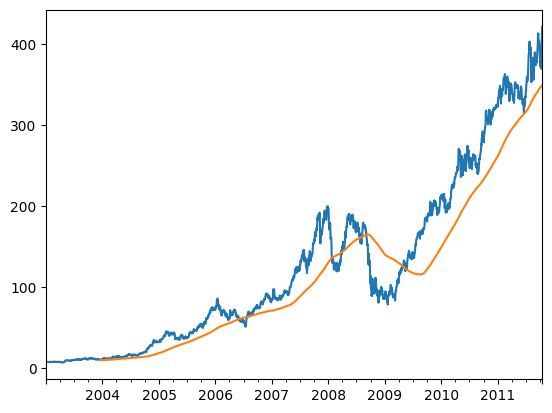

In [ ]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot()  # moving avg of 250 elements

In [76]:
# can also roll by time periods - useful for irregular time series:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000
